In [1]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.remover import UniversalStripeRemover


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. Data Preparation

In [2]:
src_img = Image.open("asset/sample.png").convert("L")
img_np = np.array(
    object = src_img,
    dtype = np.float32,
) / 255.0
f_tensor = torch.from_numpy(img_np)

print(f"Shape: {f_tensor.shape}")

Shape: torch.Size([487, 757])


## 2. Model Initialization

In [3]:
remover = UniversalStripeRemover(
    mu1 = 0.33,
    mu2 = 0.003,
    device = DEVICE,
)

## 3. Tiled Processing Execution (n=1, 2, 3)

In [4]:
results = {}
timings = {}

for n_tile in [1, 2, 3]:
    start_time = time.perf_counter()
    results[n_tile] = remover.process_tiled(
        image = f_tensor,
        n = n_tile,
        iterations = 500,
        overlap = 64,
        verbose = True,
    )
    timings[n_tile] = time.perf_counter() - start_time
    print(f"\nn={n_tile} took {timings[n_tile]:.2f}s")

Iteration: 500 / 500

n=1 took 2.70s
Tiling 2x2: 4 tiles of 366x501, overlap=61
Iteration: 500 / 500

n=2 took 1.81s
Tiling 3x3: 9 tiles of 243x333, overlap=40
Iteration: 500 / 500

n=3 took 1.90s


## 4. Visual Comparison & Residuals

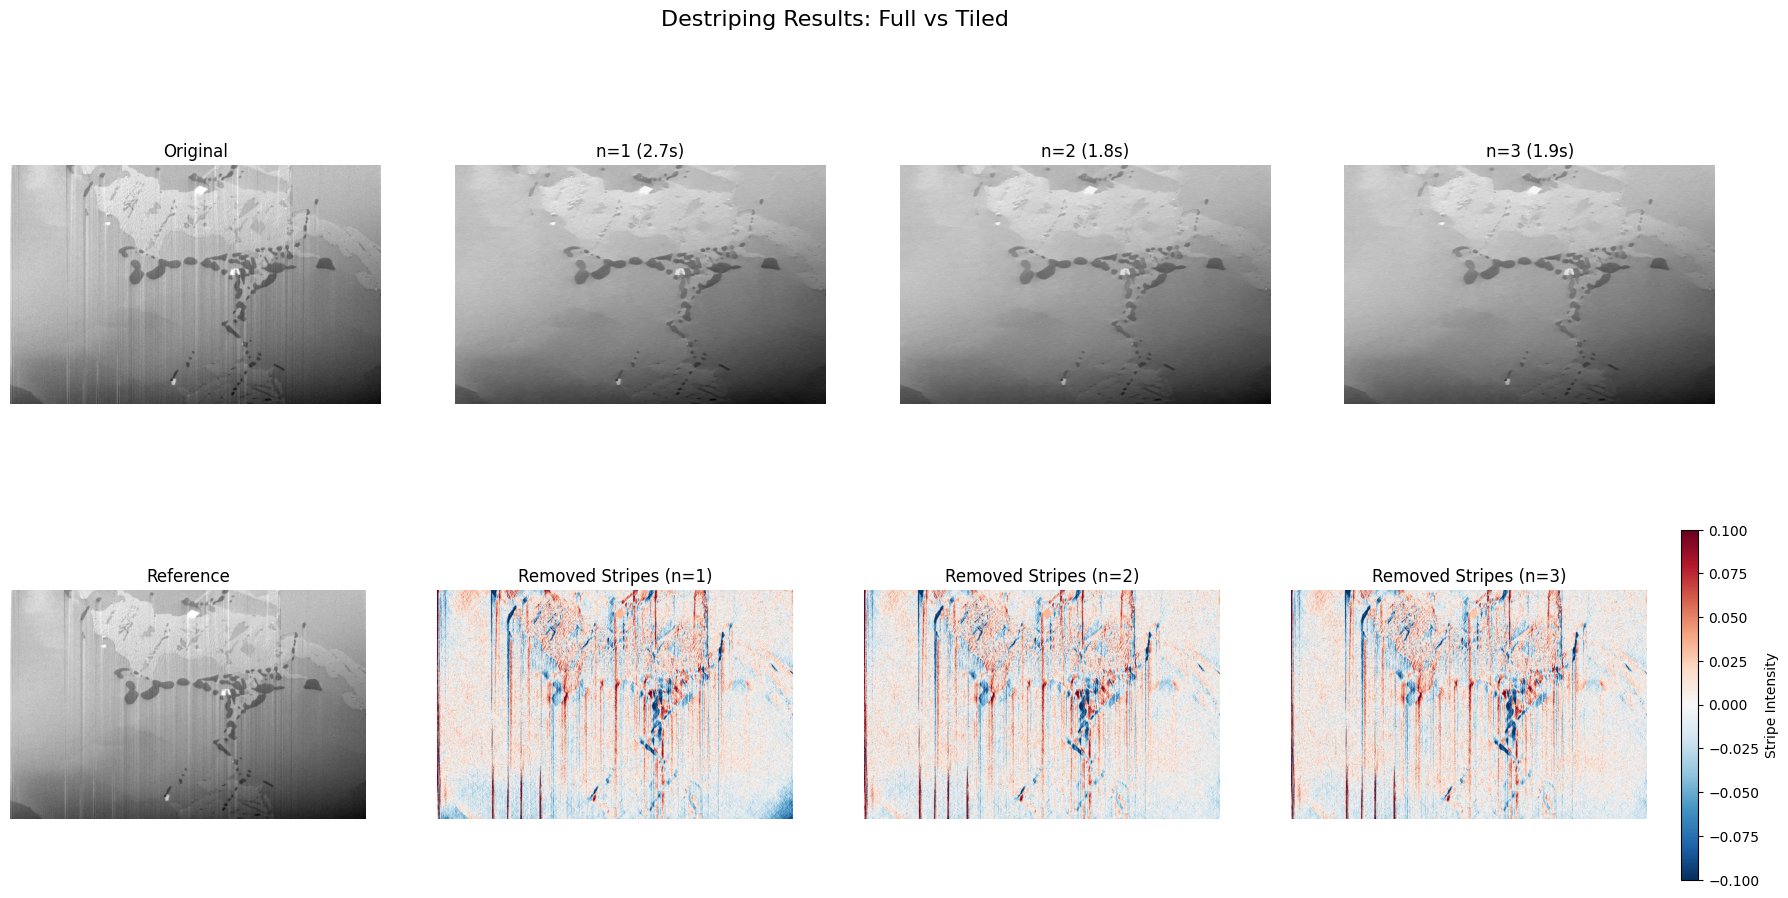

In [5]:
fig, axes = plt.subplots(
    nrows = 2,
    ncols = 4,
    figsize = (22, 10),
)

axes[0, 0].imshow(
    X = f_tensor.numpy(),
    cmap = "gray",
)
axes[0, 0].set_title("Original")

for idx, n in enumerate([1, 2, 3]):
    ax = axes[0, idx + 1]
    ax.imshow(
        X = results[n].numpy(),
        cmap = "gray",
    )
    ax.set_title(f"n={n} ({timings[n]:.1f}s)")

V_MIN, V_MAX = -0.1, 0.1
axes[1, 0].imshow(
    X = f_tensor.numpy(),
    cmap = "gray",
)
axes[1, 0].set_title("Reference")

for idx, n in enumerate([1, 2, 3]):
    ax = axes[1, idx + 1]
    residual = (f_tensor - results[n]).numpy()
    im = ax.imshow(
        X = residual,
        cmap = "RdBu_r",
        vmin = V_MIN,
        vmax = V_MAX,
    )
    ax.set_title(f"Removed Stripes (n={n})")

for ax in axes.flat:
    ax.axis("off")

fig.colorbar(
    mappable = im,
    ax = axes[1, :].tolist(),
    fraction = 0.02,
    pad = 0.02,
    label = "Stripe Intensity",
)
plt.suptitle("Destriping Results: Full vs Tiled", fontsize=16)
plt.show()

## 5. Seamlessness Check (Zoom into Boundaries)

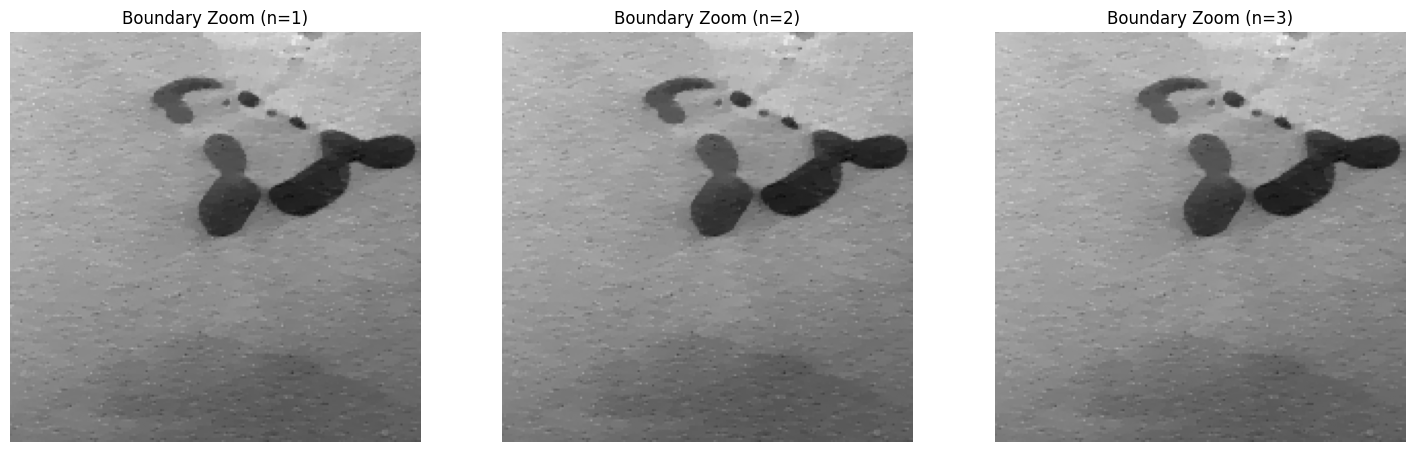

In [6]:
h, w = f_tensor.shape
fig, axes = plt.subplots(
    nrows = 1,
    ncols = 3,
    figsize = (18, 6),
)

for idx, n in enumerate([1, 2, 3]):
    ax = axes[idx]
    zoom_crop = results[n][h//2 - 100 : h//2 + 100, w//3 - 100 : w//3 + 100]
    ax.imshow(
        X = zoom_crop,
        cmap = "gray",
)
    ax.set_title(f"Boundary Zoom (n={n})")
    ax.axis("off")

plt.show()

## 6. Horizontal Line Profiles

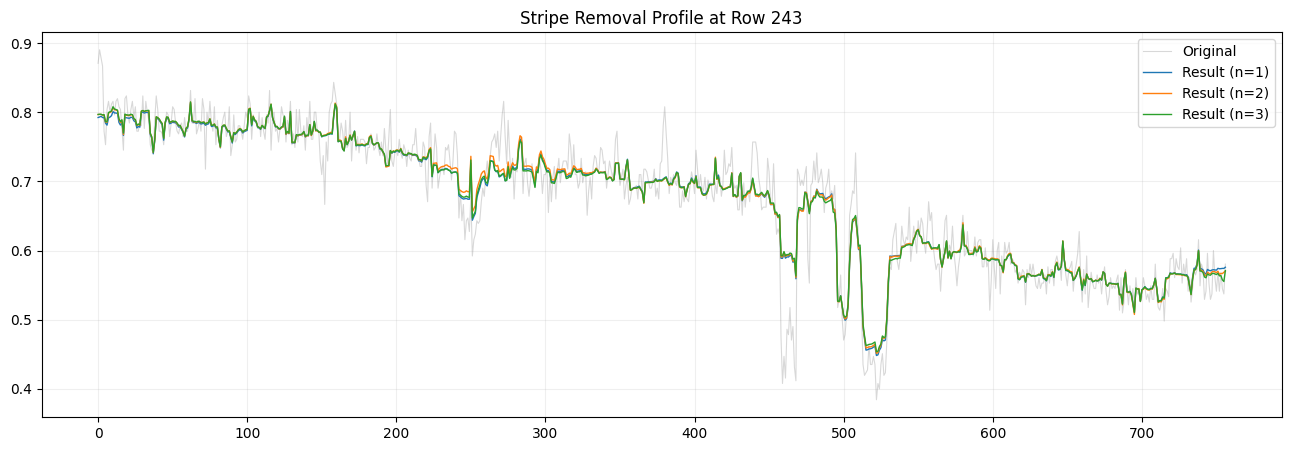

In [7]:
target_row = h // 2
plt.figure(figsize=(16, 5))

plt.plot(
    f_tensor[target_row, :].numpy(),
    alpha = 0.3,
    label = "Original",
    color = "gray",
    linewidth = 0.8,
)

for n in [1, 2, 3]:
    plt.plot(
        results[n][target_row, :].numpy(),
        label = f"Result (n={n})",
        linewidth = 1.0,
    )

plt.legend()
plt.title(f"Stripe Removal Profile at Row {target_row}")
plt.grid(True, alpha=0.2)
plt.show()

## 7. Quantitative Metrics (Consistency vs n=1)

In [8]:
ref_tensor = results[1]
header = f"{'n':>5} | {'Rel. Diff':>15} | {'Max Diff':>10} | {'PSNR':>10}"
print(header)
print("-" * len(header))

for n in [1, 2, 3]:
    diff_map = results[n] - ref_tensor
    rel_err = diff_map.norm() / (ref_tensor.norm() + 1e-9)
    max_err = diff_map.abs().max()
    
    mse = ((f_tensor - results[n])**2).mean()
    psnr = 10 * np.log10(1.0 / mse.item())
    
    print(f"{n:>5} | {rel_err.item():>15.2e} | {max_err.item():>10.4f} | {psnr:>10.2f}")

    n |       Rel. Diff |   Max Diff |       PSNR
-------------------------------------------------
    1 |        0.00e+00 |     0.0000 |      30.51
    2 |        7.14e-03 |     0.0997 |      30.68
    3 |        7.78e-03 |     0.1069 |      30.63


## 8. Adjoint Operator Consistency Test

In [9]:
r = UniversalStripeRemover(device="cpu")
shape = (1, 32, 32)
torch.manual_seed(seed=42)

print("=== Adjoint Consistency: <Df, g> == <f, D^T g> ===")
header_adj = f"{'Operator':<12} {'<Df, g>':>16} {'<f, D^T g>':>16} {'Rel Error':>12} {'':>5}"
print(header_adj)
print("-" * len(header_adj))

all_pass = True
labels = ["vert(0)", "26.6L", "45L", "26.6R", "45R"]

for mode in range(5):
    f_vec = torch.randn(size=shape)
    g_vec = torch.randn(size=shape)
    d_f = r._dir_diff(x=f_vec, mode=mode)
    dt_g = torch.zeros_like(input=g_vec)
    r._adj_dir(
        target = dt_g,
        q = g_vec,
        mode = mode,
        a = 1.0,
    )
    dt_g = -dt_g
    lhs = torch.sum(input=d_f * g_vec).item()
    rhs = torch.sum(input=f_vec * dt_g).item()
    err = abs(lhs - rhs) / (abs(lhs) + 1e-12)
    ok = err < 1e-5
    all_pass = all_pass and ok
    status = "PASS" if ok else "FAIL"
    print(f"{labels[mode]:<12} {lhs:>16.8f} {rhs:>16.8f} {err:>12.2e} {status:>5}")

for dim, name in [(1, "grad_h"), (2, "grad_v")]:
    f_vec = torch.randn(size=shape)
    g_vec = torch.randn(size=shape)
    d_f = r._fwd(x=f_vec, dim=dim)
    dt_g = torch.zeros_like(input=g_vec)
    if dim == 1:
        r._adj_grad(target=dt_g, ph=g_vec, pv=torch.zeros_like(input=g_vec), a=1.0)
    else:
        r._adj_grad(target=dt_g, ph=torch.zeros_like(input=g_vec), pv=g_vec, a=1.0)
    dt_g = -dt_g
    lhs = torch.sum(input=d_f * g_vec).item()
    rhs = torch.sum(input=f_vec * dt_g).item()
    err = abs(lhs - rhs) / (abs(lhs) + 1e-12)
    ok = err < 1e-5
    all_pass = all_pass and ok
    status = "PASS" if ok else "FAIL"
    print(f"{name:<12} {lhs:>16.8f} {rhs:>16.8f} {err:>12.2e} {status:>5}")

print()
print("All tests PASSED" if all_pass else "Some tests FAILED")

=== Adjoint Consistency: <Df, g> == <f, D^T g> ===
Operator              <Df, g>       <f, D^T g>    Rel Error      
-----------------------------------------------------------------
vert(0)           29.85549927      29.85549927     0.00e+00  PASS
26.6L           -100.50485229    -100.50484467     7.59e-08  PASS
45L              -67.93233490     -67.93232727     1.12e-07  PASS
26.6R            -17.86000252     -17.86001205     5.34e-07  PASS
45R               37.39154053      37.39154053     0.00e+00  PASS
grad_h           -27.56414986     -27.56415558     2.08e-07  PASS
grad_v           -40.49198151     -40.49198151     0.00e+00  PASS

All tests PASSED
